In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
from tqdm import tqdm
import itertools
import os
import numpy as np
import scipy.sparse
import pandas as pd
import re
import importlib.util
import sys
import scanpy as sc
from argparse import Namespace
import seaborn as sns

import math

from scipy.spatial import distance
from scipy.cluster import hierarchy
import scipy.stats as stats
import scipy

sc.set_figure_params(dpi=80)
plt.rcParams['axes.grid'] = False

In [ ]:
import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['Arial']})


In [ ]:
SAVE_FIGURES = False
if SAVE_FIGURES:
    sc.set_figure_params(dpi=300)
else:
    sc.set_figure_params(dpi=80)

figure_path = os.path.join('Figures')
os.makedirs(figure_path, exist_ok=True)

from pathlib import Path
sc._settings.ScanpyConfig.figdir = Path(figure_path)
plt.rcParams['axes.grid'] = False


In [ ]:
%matplotlib inline
%config InlineBackend.figure_format='retina'


General functions

In [ ]:
def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = np.array([bind.get(itm, None) for itm in a])  # None can be replaced by any other "not in b" value
    result = [result, np.array([not x is None for x in result])]
    return result

def grep(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[valid_entries]

def grep_exclude(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[np.logical_not(valid_entries)]

def write_object(myObject, file):
    import dill
    with open(file, 'wb') as f:
        f.write(dill.dumps(myObject))

def read_object(file):
    import dill
    with open(file, 'rb') as f:
        myObject = dill.loads(f.read())
    return myObject

adata utilities

In [ ]:
def marker_genes_for_cell_group(adata, query_cells, reference_cells = None):
    if reference_cells is None:
        reference_cells = np.array([True] * adata.n_obs)
    adata.obs['group_temp'] = query_cells
    valid_cells = np.logical_or(query_cells, reference_cells)
    adata_sub = adata[valid_cells,:].copy()
    adata_sub.obs['group_temp'] = ['query' if x else 'reference' for x in adata_sub.obs['group_temp']]
    sc.tl.rank_genes_groups(adata_sub, groupby='group_temp')
    sc.tl.dendrogram(adata_sub, groupby='group_temp')
    sc.pl.rank_genes_groups_dotplot(adata_sub, groupby='group_temp', n_genes=50)

def filter_coordinates(coord, xlim, ylim):
    if isinstance(coord, pd.DataFrame):
        coord = coord.to_numpy()
    valid_points = (coord[:,0] > xlim[0]) & (coord[:,0] < xlim[1]) & (coord[:,1] > ylim[0]) & (coord[:,1] < ylim[1])
    return valid_points

def query_region(adata, coord, xlim, ylim):
    valid_points = filter_coordinates(adata.obsm[coord], xlim, ylim)
    adata_sub = adata[valid_points,:].copy()
    return(adata_sub)

def random_adata_subset(adata, scaling = 0.1):
    import random
    cell_indexes = list(range(adata.n_obs))
    random_indexes = random.sample(cell_indexes, int(adata.n_obs * scaling))
    adata_sub = adata[random_indexes,:].copy()
    return(adata_sub)

Matrix utilities

In [ ]:
def create_diagonal_matrix(v, total_cells):
    cell_indexes = np.array(list(range(total_cells)))
    diagonal_matrix = scipy.sparse.csr_matrix((v,(cell_indexes, cell_indexes)), shape = [total_cells, total_cells])
    return(diagonal_matrix)

def get_average_neighborhood_expression(expression_matrix, spatial_neighborhood, anchor_cells = None, neighbor_cells = None):
    if anchor_cells is None:
        anchor_cells = np.array([True] * expression_matrix.shape[0])
    if neighbor_cells is None:
        neighbor_cells = np.array([True] * expression_matrix.shape[0])
    X_neighbors = expression_matrix[neighbor_cells,:].copy()
    spatial_neighborhood = spatial_neighborhood[anchor_cells,:].copy()[:,neighbor_cells].copy()
    num_neighbors_per_anchor = np.ravel(spatial_neighborhood.sum(axis=1))
    n_anchors = spatial_neighborhood.shape[0]
    normalization_matrix = create_diagonal_matrix(1/num_neighbors_per_anchor, n_anchors)
    average_expression_matrix = normalization_matrix @ spatial_neighborhood @ X_neighbors
    return(average_expression_matrix)

def get_total_neighborhood_expression(expression_matrix, spatial_neighborhood, anchor_cells = None, neighbor_cells = None):
    if anchor_cells is None:
        anchor_cells = np.array([True] * expression_matrix.shape[0])
    if neighbor_cells is None:
        neighbor_cells = np.array([True] * expression_matrix.shape[0])
    X_neighbors = expression_matrix[neighbor_cells,:].copy()
    spatial_neighborhood = spatial_neighborhood[anchor_cells,:].copy()[:,neighbor_cells].copy()
    total_expression_matrix = spatial_neighborhood @ X_neighbors
    return(total_expression_matrix)    

def get_neighborhood_fraction(spatial_neighborhood, boolean_variable):
    n_cells = spatial_neighborhood.shape[0]
    cell_indexes = np.array(list(range(n_cells)))
    masked_matrix = mask_neighborhood_columns(spatial_neighborhood, boolean_variable)
    boolean_fraction = np.ravel(masked_matrix.sum(axis=1)) / np.ravel(spatial_neighborhood.sum(axis=1))
    return(boolean_fraction)

def get_neighborhood_count(spatial_neighborhood, boolean_variable):
    n_cells = spatial_neighborhood.shape[0]
    cell_indexes = np.array(list(range(n_cells)))
    masked_matrix = mask_neighborhood_columns(spatial_neighborhood, boolean_variable)
    boolean_count = np.ravel(masked_matrix.sum(axis=1)) 
    total_count = np.ravel(spatial_neighborhood.sum(axis=1))
    return(boolean_count, total_count)

def mask_neighborhood_columns(spatial_neighborhood, mask):
    mask_matrix = create_diagonal_matrix(mask, spatial_neighborhood.shape[0])
    masked_neighborhood = spatial_neighborhood @ mask_matrix
    return(masked_neighborhood)

def mask_neighborhood_rows(spatial_neighborhood, mask):
    mask_matrix = create_diagonal_matrix(mask, spatial_neighborhood.shape[0])
    masked_neighborhood = mask_matrix @ spatial_neighborhood
    return(masked_neighborhood)

def row_normalize_sparse_matrix(mat):
    normalization_vector = np.ravel(mat.sum(axis=1))
    normalization_factor = create_diagonal_matrix(1/normalization_vector, mat.shape[0])
    normalized_matrix = normalization_factor @ mat * np.median(normalization_vector)
    return(normalized_matrix)

Neihgborhood utilities

In [ ]:
def neighbors_gpu(mat, k=30):
    X_mat = cupy.array(mat)
    model = cuml.neighbors.NearestNeighbors(n_neighbors=k)
    model.fit(X_mat)
    distances, indices = model.kneighbors(X_mat)
    return(distances, indices)

def get_cugraph_from_csr_matrix(mat):
    sources, targets = mat.nonzero()
    edges = cudf.concat([
        cudf.Series(sources, name='source'), # sources
        cudf.Series(targets, name='destination'), # targets
    ], axis=1)
    G = cugraph.from_cudf_edgelist(edges)
    return(G)

def get_cugraph_from_array(mat):
    targets = np.ravel(mat)
    n_neighbors_per_cell = [len(x) for x in mat]
    sources = np.ravel([[i]*k for i,k in zip(range(mat.shape[0]), n_neighbors_per_cell)])
    edges = cudf.concat([
        cudf.Series(sources, name='source'), # sources
        cudf.Series(targets, name='destination'), # targets
    ], axis=1)
    G = cugraph.from_cudf_edgelist(edges)
    return(G)

def get_spatial_knn(adata, k = 30):
    # Compute spatial knn
    spatial_knn = neighbors_gpu(adata.obsm['X_spatial'])[1]
    targets = np.ravel(spatial_knn).get()
    n_neighbors_per_cell = [len(x) for x in spatial_knn]
    sources = np.ravel([[i]*k for i,k in zip(range(spatial_knn.shape[0]), n_neighbors_per_cell)])
    df = pd.DataFrame({'sources': sources, 'targets': targets})
    return(df)

def compute_sample_neighborhoods(adata, slide_key, cell_type_key, selected_cell_types = [], k = 30):
    
    # Pre-compute cell_type_filter
    if(len(selected_cell_types) == 0):
        selected_cell_types = np.unique(adata.obs[cell_type_key])
    cell_type_filter = ismember(adata.obs[cell_type_key], selected_cell_types)[1]

    # Compute spatial neighborhoods per sample
    sources = np.array([], dtype=np.uint32)
    targets = np.array([], dtype=np.uint32)

    unique_slides = np.unique(adata.obs[slide_key])
    for my_slide in tqdm(unique_slides):
        slide_filter = adata.obs[slide_key] == my_slide
        selected_cell_indexes_slide = np.where(slide_filter)[0]
        adata_sub = adata[slide_filter,:].copy()
        
        selected_cells = np.logical_and(slide_filter, cell_type_filter)
        selected_cell_indexes_query = np.where(selected_cells)[0]
        
        result = get_spatial_knn(adata_sub, k=k)        
        sources = np.hstack((sources, selected_cell_indexes_slide[result['sources'].to_numpy().astype(np.uint32)]))
        targets = np.hstack((targets, selected_cell_indexes_slide[result['targets'].to_numpy().astype(np.uint32)]))
        
    spatial_neighborhood = scipy.sparse.csr_matrix(([1] * len(sources), (sources, targets)), shape = [adata.n_obs] * 2).astype(np.uint8)
    return(spatial_neighborhood)

def compute_distances_within_neighborhood(adata, obsm_field, neighbor_graph):
    """Computes euclidian distances within neighborhoods using arbitrary feature matrix

    Args:
        - adata: base adata object
        - obsm_field: feature matrix within the adata object (e.g. "X_spatial")
        - neighbor_graph: scipy.sparse.csr_matrix containing binary neighbor assignments. The number of rows is equal to adata.n_obs

    Returns
    -------
        - scipy.sparse.csr_matrix with distances between source and query cells, as specified in neighbor_graph.
    """
    assert (
        adata.n_obs == neighbor_graph.shape[0]
    ), "The number of cells in adata is different from number of cells in neighbor_graph"
    sources, targets = neighbor_graph.nonzero()
    source_vectors = adata.obsm[obsm_field][sources, :]
    target_vectors = adata.obsm[obsm_field][targets, :]
    dists = np.sqrt(np.power(source_vectors - target_vectors, 2).sum(axis=1))
    spatial_distance = scipy.sparse.csr_matrix((dists, (sources, targets)), shape = neighbor_graph.shape)
    return spatial_distance

Thresholding utilities

In [ ]:
# Modified from skimage package
def threshold_triangle(hist, upper = True):
    bin_centers = hist[1]
    hist = hist[0].copy()
    nbins = len(hist)

    # Find peak, lowest and highest gray levels.
    arg_peak_height = np.argmax(hist)
    peak_height = hist[arg_peak_height]
    arg_low_level, arg_high_level = np.flatnonzero(hist)[[0, -1]]

    if(upper):
        flip=True
    else:
        flip=False
    # Flip is True if left tail is shorter.
    #flip = arg_peak_height - arg_low_level < arg_high_level - arg_peak_height
    if flip:
        hist = hist[::-1]
        arg_low_level = nbins - arg_high_level - 1
        arg_peak_height = nbins - arg_peak_height - 1

    # If flip == True, arg_high_level becomes incorrect
    # but we don't need it anymore.
    del(arg_high_level)

    # Set up the coordinate system.
    width = arg_peak_height - arg_low_level
    x1 = np.arange(width)
    y1 = hist[x1 + arg_low_level]

    # Normalize.
    norm = np.sqrt(peak_height**2 + width**2)
    peak_height /= norm
    width /= norm

    # Maximize the length.
    # The ImageJ implementation includes an additional constant when calculating
    # the length, but here we omit it as it does not affect the location of the
    # minimum.
    length = peak_height * x1 - width * y1
    arg_level = np.argmax(length) + arg_low_level

    if flip:
        arg_level = nbins - arg_level - 1

    return bin_centers[arg_level]

In [ ]:
def filter_coordinates(coord, xlim, ylim):
    if isinstance(coord, pd.DataFrame):
        coord = coord.to_numpy()
    valid_points = (coord[:,0] > xlim[0]) & (coord[:,0] < xlim[1]) & (coord[:,1] > ylim[0]) & (coord[:,1] < ylim[1])
    return valid_points

def query_region(adata, coord, xlim, ylim):
    valid_points = filter_coordinates(adata.obsm[coord], xlim, ylim)
    adata_sub = adata[valid_points,:].copy()
    return(adata_sub)

### Key parameters

In [ ]:
selected_radius = 60
neighborhood_mode = 'circle'

### Import datasets

In [ ]:
adata_all = sc.read_h5ad('../data/Reyes_Xenium_TIER_all_SUBSET_all__annotated.h5ad')
adata_DC = sc.read_h5ad('../data/Reyes_Xenium_TIER_tier3_SUBSET_Premalignant0.h5ad')
adata_neighborhood = sc.read_h5ad('../data/Reyes_Xenium_TIER_all_SUBSET_all__spatial_neighborhood.h5ad')

### Append pre-computed gastric-progenitor DC to adata_epi object

In [ ]:
# Bin diffusion component and transfer all DC values into adata_epi object
diff_comp = adata_DC.obs["progenitor_DC"].to_numpy()

n_bins = 100
breaks = np.quantile(diff_comp, np.linspace(start=0, stop=1, num=n_bins+1))
progenitor_DC_digitized = np.digitize(diff_comp, breaks)

progenitor_DC = np.array([np.nan] * adata_all.n_obs, dtype = np.float32)
progenitor_DC[np.where(ismember(adata_all.obs_names, adata_DC.obs_names)[1])[0]] = diff_comp
adata_all.obs['progenitor_DC_original'] = progenitor_DC.copy()

progenitor_DC = np.array([np.nan] * adata_all.n_obs)
progenitor_DC[np.where(ismember(adata_all.obs_names, adata_DC.obs_names)[1])[0]] = progenitor_DC_digitized
adata_all.obs['progenitor_DC_binned'] = progenitor_DC.copy()

In [ ]:
selected_conditions = np.unique(adata_all.obs['condition'][np.logical_not(np.isnan(adata_all.obs['progenitor_DC_original']))])
valid_cells = ismember(adata_all.obs['condition'], selected_conditions)[1]
adata_all = adata_all[valid_cells,:].copy()
adata_neighborhood = adata_neighborhood[valid_cells,:].copy()

In [ ]:
spatial_distance = compute_distances_within_neighborhood(adata_all, "X_spatial", adata_neighborhood.obsp['spatial_neighborhood'])

In [ ]:
def first_index(v, default = 'first'):
    if(len(v) > 0):
        result = np.min(v)
    elif default == 'first':
        result = 0
    else:
        result = len(v) - 1
    return(result)

def smooth_trends(trends, bandwidth):
    linspace = np.array([list(range(0,trends.shape[0]))] * 2).T
    d = distance.squareform(distance.pdist(linspace))
    kernel = np.exp(-np.power(d,2) / np.power(bandwidth, 2) / 2) / np.sqrt(2*math.pi*bandwidth)
    mat = np.dot(trends.to_numpy().T, kernel).T
    return(pd.DataFrame(mat, index = trends.index, columns = trends.columns))

def order_trends(trends, window_length = 5):
    trends = trends.copy()
    
    # Time of downregulation
    accumulated_reduction = np.cumsum(trends < 0, axis=0)
    DOWN_point = [first_index(np.where(accumulated_reduction.iloc[:,i] > window_length)[0], default = 'first') for i in range(trends.shape[1])]
    ordering = np.argsort(DOWN_point, kind = 'mergesort')    
    trends = trends.iloc[:, ordering].copy()
    
    # Time of upregulation
    accumulated_induction = np.cumsum(trends > 0, axis=0)
    UP_point = [first_index(np.where(accumulated_induction.iloc[:,i] > window_length)[0], default = 'first') for i in range(trends.shape[1])]
    ordering = np.argsort(UP_point, kind = 'mergesort')    
    trends = trends.iloc[:, ordering].copy()

    return(trends.columns.to_numpy())

def plot_gene_trends(trends, selected_genes, vmin = -1, vmax = 1, y_lines = None, reorder_genes = True, swap_axes = False, figsize_fixed = 3, figsize_scale = 0.2):
    if(reorder_genes):
        gene_ordering = order_trends(smooth_trends(trends, 3), window_length=10)
        selected_genes = gene_ordering[ismember(gene_ordering, selected_genes)[1]]
        
    gene_ordering = order_trends(smooth_trends(trends, 3), window_length=10)
    selected_genes = gene_ordering[ismember(gene_ordering, selected_genes)[1]]
    
    
    trends = trends.loc[:,selected_genes].copy()
    if(not swap_axes):
        f = plt.figure(figsize=[figsize_fixed, figsize_scale*len(selected_genes)])
        trends = trends.loc[:,selected_genes].T
    else:
        f = plt.figure(figsize=[figsize_scale*len(selected_genes), figsize_fixed])
        trends.loc[:,selected_genes]
    im = plt.imshow(trends, aspect='auto', vmin=vmin, vmax=vmax, cmap='RdBu_r', interpolation = 'None')
    if not y_lines is None:
        for my_line in y_lines:
            plt.plot([my_line, my_line], f.gca().get_ylim(), 'k--')
    if(not swap_axes):
        plt.yticks(np.array(list(range(len(selected_genes)))), labels = selected_genes)
    else:
        plt.xticks(np.array(list(range(len(selected_genes)))), labels = selected_genes, rotation = 90)
    plt.xlabel("Gastric Progenitor DC")
    plt.grid(False)
    cb_ax = f.add_axes([0.5,0.5,0.02,0.25])
    f.colorbar(im,orientation='vertical',cax=cb_ax, fraction=0.01, label='z-score')
    return(trends)

Xenium_myeloid_measured = [
    'Mafb','Cd163','Ifi205','Lifr','Maf','Gas6',
    'Itgam','Csf1r','Ifitm1','Adgre1','Ifnar1','Lair1',
    'Csf3r','Cxcr2','Vcan','Mmp9','Ccl2','Cd44','Mki67','Skil',
    'Tgfbi','Serpine1','Plaur','Emilin2','Socs3','Cd274','Il18',
    'Csf2rb','Ccr2','Itgax','Plat','Plau', 'Cxcl9', 'Cxcl10', 'Cxcl12']

Xenium_fibroblast_measured = [
    'Dpt','Cxcl12','Tnxb','Rspo1','Lifr','Pdgfra','Gas6','Ngfr',
    'Epha3','Ptch2','Epha4','Gli1','Ptch1','Spry1','Fgfr2','Igf2',
    'Emp1','Postn','Tnc','Serpine1','Tagln','Lox','Plaur','Cdkn2b',
    'Msn','Tgfb1', 'Tgfbr1', 'Pdgfrb', 'Inhbb','Ccn2','Plat', 'Smo', 'Ccn2']

Xenium_epithelial_measured = [
    'Oasl2', 'Irf7', 'Gsta1', 'F5', 'Itga6', 'Shh', 'Elf3', 'Anxa10', 
    'Lgals4', 'Onecut2', 'Wnt5a', 'Itga1', 'Rbpjl', 'Dusp4', 'Dusp6', 
    'Cp', 'Msln', 'Ifngr1', 'Plaur', 'Il18r1', 'Il18rap', 'Lif', 'Msn', 
    'Nes', 'Plat', 'Cdkn2b', 'Cdkn1a', 'Hmga2', 'Piezo2', 'Plau', 'Pdgfb',
    'Serpine1', 'Csf2', 'Tgfb1', 'Tgfb3', 'Dusp5', 'Kras', 'Vim', 'ENSMUST00000060501', 'ENSMUST00000107131'
]

In [ ]:
from sklearn.preprocessing import StandardScaler
def compute_gene_trends(adata, bin_obs, layer, cell_filter = None, gene_filter = None, zscore = 'before_filtering', log1p = True):
    # Prepare cell and gene filters
    if cell_filter is None:
        cell_filter = np.array([True] * adata.n_obs)
    if gene_filter is None:
        gene_filter = np.array([True] * adata.n_vars)
    
    # Prepare expression matrix
    if(layer == 'X'):
        mat = X.copy()
    else:
        mat = adata.layers[layer].copy()
    if scipy.sparse.issparse(mat):
        mat = np.array(mat.todense())

    if log1p:
        mat = np.log1p(mat)

    # Deal with zscoring
    if zscore == 'before_filtering':
        mat = StandardScaler().fit_transform(mat[:,gene_filter])
        mat = mat[cell_filter,:]
    if zscore == 'after_filtering':
        mat = StandardScaler().fit_transform(mat[cell_filter,:][:,gene_filter])
    if zscore == 'no_zscore':
        mat = mat[cell_filter,:][:,gene_filter]

    df = pd.DataFrame(mat, index = adata.obs_names[cell_filter], columns = adata.var_names[gene_filter])
    # Set binned observation
    df['binned_obs'] = adata.obs[bin_obs].to_numpy()[cell_filter]

    # Aggregate matrix
    summarized_df_mean = df.groupby('binned_obs').agg('mean')
    summarized_count = df.groupby('binned_obs').agg('count')
    result = {
        'mean': summarized_df_mean,
        'count': summarized_count,
    }
    return(result, df)
    
def process_radius(adata_sub, spatial_neighborhood, spatial_distance, selected_radius, force = False):
    nhood_suffix = '%s%d' % (neighborhood_mode, selected_radius)
    
    # Get spatial neighborhood based on selected_radius
    print("Filtering spatial neighborhood")
    masked_array = spatial_distance.data > selected_radius
    spatial_neighborhood = spatial_neighborhood.copy()
    spatial_neighborhood.data[masked_array] = 0
    spatial_neighborhood.eliminate_zeros()

    # Compute statistics per neighborhood
    boolean_mask = np.logical_not(np.isnan(adata_sub.obs['progenitor_DC_original']))
    spatial_neighborhood_sub = spatial_neighborhood[:,boolean_mask].copy()
    progenitor_DC = np.array([adata_sub.obs['progenitor_DC_original'].to_numpy()[boolean_mask].copy()]).T
    neighborhood_total_DC = np.ravel(spatial_neighborhood_sub @ progenitor_DC)
    neighborhood_count = np.ravel(spatial_neighborhood_sub.sum(axis=1))
    adata_sub.obs['progenitor_neighborhood_score'] = neighborhood_total_DC / neighborhood_count

    # Compute cell type-specific expression matrices
    print("Processing epithelial")
    epi_total = get_total_neighborhood_expression(
        expression_matrix=adata_sub.layers['raw'], 
        spatial_neighborhood=spatial_neighborhood, 
        neighbor_cells = adata_sub.obs['cell_type_0'] == 'Epithelial'
    )
    print("Processing fibroblast")
    fib_total = get_total_neighborhood_expression(
        expression_matrix=adata_sub.layers['raw'], 
        spatial_neighborhood=spatial_neighborhood, 
        neighbor_cells = adata_sub.obs['cell_type_0'] == 'Fibroblast'
    )
    print("Processing myeloid")
    myeloid_total = get_total_neighborhood_expression(
        expression_matrix=adata_sub.layers['raw'], 
        spatial_neighborhood=spatial_neighborhood, 
        neighbor_cells = adata_sub.obs['cell_type_0'] == 'Immune_Myeloid'
    )
    print('Computing normalized neighborhood expression matrices')
    epi_normalized = row_normalize_sparse_matrix(epi_total)
    fib_normalized = row_normalize_sparse_matrix(fib_total)
    myeloid_normalized = row_normalize_sparse_matrix(myeloid_total)
    adata_sub.layers['epi_normalized'] = epi_normalized.copy()
    adata_sub.layers['fib_normalized'] = fib_normalized.copy()
    adata_sub.layers['myeloid_normalized'] = myeloid_normalized.copy()

    # Compute statistics per neighborhood
    print('Computing neighborhood statistics')
    #adata_sub.obs['neighborhood_total'] = np.ravel(spatial_neighborhood.sum(axis = 1))
    #adata_sub.obs['epithelial_count'] = get_neighborhood_count(spatial_neighborhood, adata_sub.obs['cell_type_0'] == 'Epithelial')[0]
    #adata_sub.obs['fibroblast_count'] = get_neighborhood_count(spatial_neighborhood, adata_sub.obs['cell_type_0'] == 'Fibroblast')[0]
    #adata_sub.obs['myeloid_count'] = get_neighborhood_count(spatial_neighborhood, adata_sub.obs['cell_type_0'] == 'Immune_Myeloid')[0]
    #adata_sub.obs['epithelial_fraction'] = adata_sub.obs['epithelial_count'] / adata_sub.obs['neighborhood_total']
    #adata_sub.obs['fibroblast_fraction'] = adata_sub.obs['fibroblast_count'] / adata_sub.obs['neighborhood_total']
    #adata_sub.obs['myeloid_fraction'] = adata_sub.obs['myeloid_count'] / adata_sub.obs['neighborhood_total']
    progenitor_cells = ismember(adata_sub.obs['cell_type_1'], ['progenitor1', 'progenitor2'])[1]
    gastric_cells = ismember(adata_sub.obs['cell_type_1'], ['gastric', 'gastricprogenitor', 'gastric_chief', 'gastric_pit', 'gastric_Ccn2'])[1]
    adata_sub.obs['progenitor_count'] = get_neighborhood_count(spatial_neighborhood, progenitor_cells)[0]
    adata_sub.obs['gastric_count'] = get_neighborhood_count(spatial_neighborhood, gastric_cells)[0]
    #adata_sub.obs['progenitor_fraction'] = adata_sub.obs['progenitor_count'] / adata_sub.obs['epithelial_count']
    #adata_sub.obs['gastric_fraction'] = adata_sub.obs['gastric_count'] / adata_sub.obs['epithelial_count']
    adata_sub.obs['count_valid_epithelial'] = adata_sub.obs['progenitor_count'] + adata_sub.obs['gastric_count']
    
    # Bin gastric progenitor DC
    obs_to_bin = 'progenitor_neighborhood_score'
    
    # Filter cells to exclude neighborhoods with few epithelial cells that may introduce noise
    min_valid_epithelial = np.min([np.round(np.mean(adata_sub.obs['count_valid_epithelial'])), 10])
    print('Mininum valid epithelial cells: %d' % (min_valid_epithelial))
    valid_obs = np.logical_not(np.isnan(adata_sub.obs[obs_to_bin]))
    valid_obs = np.logical_and(valid_obs, adata_sub.obs['count_valid_epithelial'] > min_valid_epithelial)
    nbins = 100
    breaks = np.quantile(adata_sub.obs[obs_to_bin][valid_obs], np.linspace(start=0, stop=1, num=nbins+1))
    breaks[-1] = breaks[-1]* 1.1
    obs_digitized = np.digitize(adata_sub.obs[obs_to_bin], breaks)
    obs_axis = np.array([np.nan] * adata_sub.n_obs)
    obs_axis[valid_obs] = obs_digitized[valid_obs]
    adata_sub.obs['binned_obs'] = obs_axis.copy()
    
    print('Computing gene trends')
    # Compute gene trends
    output_dir = os.path.join('../gene_trends')
    os.makedirs(output_dir, exist_ok = True)
    output_file = os.path.join(output_dir, "adata_tier3_epi_trends_NHOODMODE_" + nhood_suffix + ".pydata")
    if not os.path.exists(output_file) or force:
        print("Processing epithelial cells")
        epi_trends, epi_df = compute_gene_trends(
            adata = adata_sub, 
            bin_obs = 'binned_obs', 
            layer = 'epi_normalized', 
            zscore= 'after_filtering',
            cell_filter = np.logical_not(np.isnan(adata_sub.obs['binned_obs'])),
            log1p = True,
            gene_filter = None
        )
        write_object(epi_trends, output_file)
    else:
        epi_trends = read_object(output_file)
    
    output_file = os.path.join(output_dir, "adata_tier3_fib_trends_NHOODMODE_" + nhood_suffix + ".pydata")
    if not os.path.exists(output_file) or force:
        print("Processing fibroblasts")
        fib_trends, fib_df = compute_gene_trends(
            adata = adata_sub, 
            bin_obs = 'binned_obs', 
            layer = 'fib_normalized', 
            zscore= 'after_filtering',
            cell_filter = np.logical_not(np.isnan(adata_sub.obs['binned_obs'])),
            log1p = True,
            gene_filter = None
        )
        write_object(fib_trends, output_file)
    else:
        fib_trends = read_object(output_file)
    
    output_file = os.path.join(output_dir, "adata_tier3_myeloid_trends_NHOODMODE_" + nhood_suffix + ".pydata")
    if not os.path.exists(output_file) or force:
        print("Processing myeloid cells")
        myeloid_trends, myeloid_df = compute_gene_trends(
            adata = adata_sub, 
            bin_obs = 'binned_obs', 
            layer = 'myeloid_normalized', 
            zscore= 'after_filtering',
            cell_filter = np.logical_not(np.isnan(adata_sub.obs['binned_obs'])),
            log1p = True,
            gene_filter = None
        )
        write_object(myeloid_trends, output_file)
    else:
        myeloid_trends = read_object(output_file)
    return epi_trends, fib_trends, myeloid_trends

In [ ]:
epi_trends, fib_trends, myeloid_trends = process_radius(adata_all, adata_neighborhood.obsp['spatial_neighborhood'], spatial_distance, 60, force = True)

In [ ]:
epi_ordered_genes = plot_gene_trends(epi_trends['mean'], Xenium_epithelial_measured, vmin = -1, vmax = 1, y_lines = [])


In [ ]:
for selected_radius in tqdm(range(10, 30, 5)):
    epi_trends, fib_trends, myeloid_trends = process_radius(adata_all, adata_neighborhood.obsp['spatial_neighborhood'], spatial_distance, selected_radius, force = True)
    #epi_ordered_genes = plot_gene_trends(epi_trends['mean'], Xenium_epithelial_measured, vmin = -1, vmax = 1, y_lines = [])
    #plt.show()

  0%|          | 0/4 [00:00<?, ?it/s]

Filtering spatial neighborhood


/data/lowe/reyesj3/repositories/temp/ipykernel_112360/6642709.py:58: RuntimeWarning: invalid value encountered in divide
  adata_sub.obs['progenitor_neighborhood_score'] = neighborhood_total_DC / neighborhood_count


Processing epithelial
Processing fibroblast
Processing myeloid
Computing normalized neighborhood expression matrices


/data/lowe/reyesj3/repositories/temp/ipykernel_112360/1954500562.py:56: RuntimeWarning: divide by zero encountered in divide
  normalization_factor = create_diagonal_matrix(1/normalization_vector, mat.shape[0])


...

/data/lowe/reyesj3/repositories/temp/ipykernel_112360/6642709.py:58: RuntimeWarning: invalid value encountered in divide
  adata_sub.obs['progenitor_neighborhood_score'] = neighborhood_total_DC / neighborhood_count


Processing epithelial
Processing fibroblast
Processing myeloid
Computing normalized neighborhood expression matrices


/data/lowe/reyesj3/repositories/temp/ipykernel_112360/1954500562.py:56: RuntimeWarning: divide by zero encountered in divide
  normalization_factor = create_diagonal_matrix(1/normalization_vector, mat.shape[0])


Computing neighborhood statistics
Mininum valid epithelial cells: 5
Computing gene trends
Processing epithelial cells
Processing fibroblasts
Processing myeloid cells


100%|██████████| 4/4 [09:36<00:00, 144.15s/it]


### Plot gene trends

Read and organize all precomputed trends

In [ ]:
possible_cell_types = ['epi', 'myeloid', 'fib']
result = []
metadata_type = []
metadata_radius = []
metadata_gene = []
selected_genes = {
    'epi': Xenium_epithelial_measured,
    'myeloid': Xenium_myeloid_measured,
    'fib': Xenium_fibroblast_measured
}

for selected_radius in tqdm(range(15, 200, 5)):
    for my_type in possible_cell_types:
        gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_" + my_type + "_trends_NHOODMODE_circle"+str(selected_radius)+".pydata")
        df = gene_trends['mean'].copy()
        df = df.loc[:, selected_genes[my_type]].copy()
        metadata_gene += df.columns.to_list()
        metadata_type += [my_type] * df.shape[1]
        metadata_radius += [selected_radius] * df.shape[1]
        df.columns = [my_type + "_" + x for x in df.columns]
        df.columns = [str(selected_radius) + "_" + x for x in df.columns]
        result.append(df)

100%|██████████| 37/37 [00:00<00:00, 173.33it/s]


In [ ]:
all_trends = pd.concat(result, axis=1)
adata_trends = sc.AnnData(all_trends.T)
adata_trends.obs['cell_type'] = np.array(metadata_type)
adata_trends.obs['radius'] = np.array(metadata_radius)
adata_trends.obs['gene_name'] = np.array(metadata_gene)


/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/anndata/_core/anndata.py:183: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Compute spearman correlations with radius 60

In [ ]:
unique_radius = np.unique(adata_trends.obs['radius'])
unique_cell_types = np.unique(adata_trends.obs['cell_type'])
reference_radius = 60
reference_radius_filter = adata_trends.obs['radius'] == reference_radius

result_stat_spearman = []
result_stat_pearson = []
result_query = []
result_reference = []
result_radius = []
result_cell_type = []
result_gene = []

for my_type in unique_cell_types:
    type_filter = adata_trends.obs['cell_type'] == my_type
    unique_genes = np.unique(adata_trends[type_filter].obs['gene_name'])
    for my_gene in unique_genes:
        gene_filter = adata_trends.obs['gene_name'] == my_gene
        unique_radii = np.unique(adata_trends[np.logical_and(type_filter, gene_filter)].obs['radius'])
        for my_radius in unique_radii:
            radius_filter = adata_trends.obs['radius'] == my_radius

            # Get reference and query trends
            query_trend = np.logical_and(type_filter, np.logical_and(gene_filter, radius_filter))
            reference_trend = np.logical_and(type_filter, np.logical_and(gene_filter, reference_radius_filter))
            
            query_name = adata_trends.obs_names[query_trend].to_numpy()
            reference_name = adata_trends.obs_names[reference_trend].to_numpy()
            
            xval = np.ravel(adata_trends.X[query_trend,:])
            yval = np.ravel(adata_trends.X[reference_trend,:])

            # Compute statistics and record results
            my_stats = scipy.stats.spearmanr(xval, yval)
            result_stat_spearman.append(my_stats.statistic)
            my_stats = scipy.stats.pearsonr(xval, yval)
            result_stat_pearson.append(my_stats.statistic)
            result_query.append(query_name[0])
            result_reference.append(reference_name[0])
            result_radius.append(my_radius)
            result_cell_type.append(my_type)
            result_gene.append(my_gene)

# Compact result
correlations_df = pd.DataFrame({
    'spearman': result_stat_spearman, 
    'pearson': result_stat_pearson, 
    'query': result_query, 
    'reference': result_reference,
    'gene': result_gene,
    'cell_type': result_cell_type,
    'radius': result_radius
})

In [ ]:
correlations_df.to_csv("Figures/Fig20251127_gene_trend_pearson_correlation_all.csv")

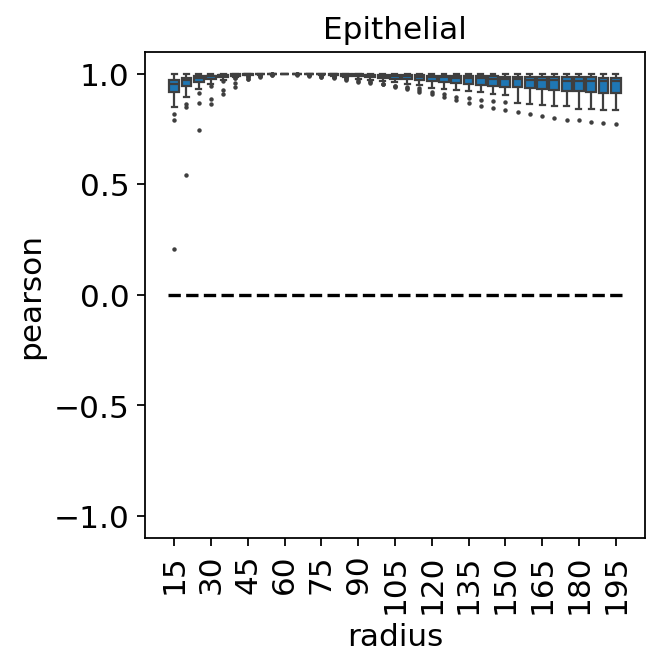

In [ ]:
data_temp = correlations_df.loc[correlations_df['cell_type'] == 'epi']
sns.boxplot(x = 'radius', y = 'pearson', data = data_temp, saturation = 1, fliersize=1)
current_xticks = np.array(plt.gca().get_xticks())
current_xtick_labels = np.array(plt.gca().get_xticklabels())
h = plt.gca().set_xticks(current_xticks[range(0,len(current_xticks),3)], labels = current_xtick_labels[range(0,len(current_xticks),3)], rotation = 90)
plt.ylim([-1.1, 1.1])
plt.plot(plt.gca().get_xlim(), [0]*2, 'k--')
plt.title("Epithelial")

df_temp = data_temp.loc[data_temp['radius'] < reference_radius,:].copy()
top_neg_corr_low_radius_epi = df_temp.iloc[np.argmin(df_temp['pearson']),:]
df_temp = data_temp.loc[data_temp['radius'] > reference_radius,:].copy()
top_neg_corr_high_radius_epi = df_temp.iloc[np.argmin(df_temp['pearson']),:]
plt.savefig("Figures/Fig20251127_gene_trend_pearson_correlation_epi.pdf")


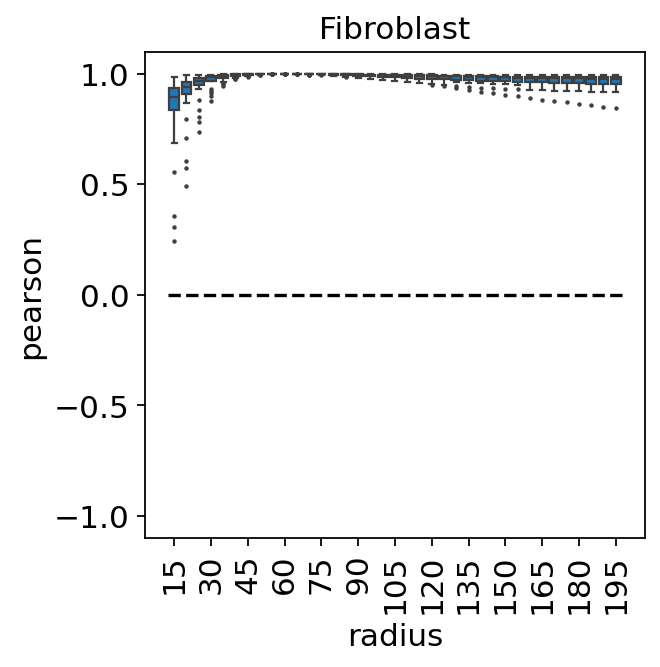

In [ ]:
data_temp = correlations_df.loc[correlations_df['cell_type'] == 'fib']
sns.boxplot(x = 'radius', y = 'pearson', data = data_temp, saturation = 1, fliersize=1)
current_xticks = np.array(plt.gca().get_xticks())
current_xtick_labels = np.array(plt.gca().get_xticklabels())
h = plt.gca().set_xticks(current_xticks[range(0,len(current_xticks),3)], labels = current_xtick_labels[range(0,len(current_xticks),3)], rotation = 90)
plt.ylim([-1.1, 1.1])
plt.plot(plt.gca().get_xlim(), [0]*2, 'k--')
plt.title("Fibroblast")

df_temp = data_temp.loc[data_temp['radius'] < reference_radius,:].copy()
top_neg_corr_low_radius_fib = df_temp.iloc[np.argmin(df_temp['pearson']),:]
df_temp = data_temp.loc[data_temp['radius'] > reference_radius,:].copy()
top_neg_corr_high_radius_fib = df_temp.iloc[np.argmin(df_temp['pearson']),:]
plt.savefig("Figures/Fig20251127_gene_trend_pearson_correlation_fib.pdf")

In [ ]:
top_neg_corr_low_radius_fib

spearman        0.563468
pearson         0.244079
query        15_fib_Emp1
reference    60_fib_Emp1
gene                Emp1
cell_type            fib
radius                15
Name: 1628, dtype: object

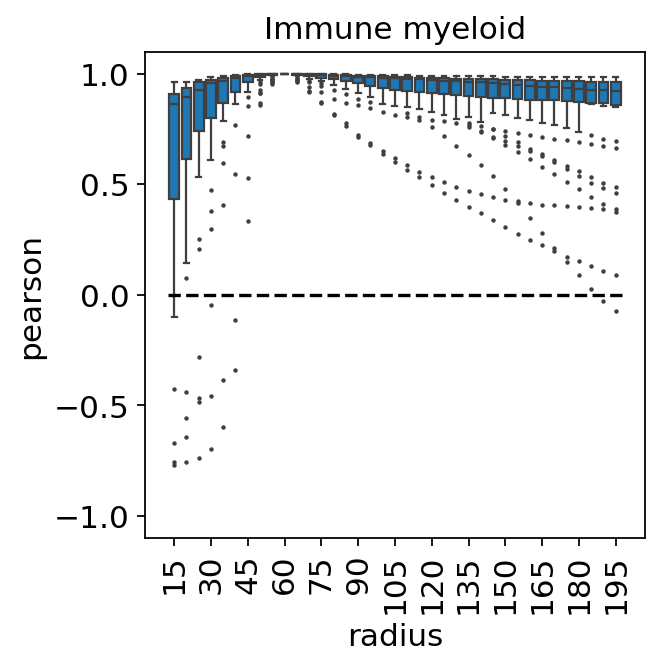

In [ ]:
import seaborn as sns
data_temp = correlations_df.loc[correlations_df['cell_type'] == 'myeloid']
sns.boxplot(x = 'radius', y = 'pearson', data = data_temp, saturation = 1, fliersize=1)
current_xticks = np.array(plt.gca().get_xticks())
current_xtick_labels = np.array(plt.gca().get_xticklabels())
h = plt.gca().set_xticks(current_xticks[range(0,len(current_xticks),3)], labels = current_xtick_labels[range(0,len(current_xticks),3)], rotation = 90)
plt.ylim([-1.1, 1.1])
plt.plot(plt.gca().get_xlim(), [0]*2, 'k--')
plt.title("Immune myeloid")

df_temp = data_temp.loc[data_temp['radius'] < reference_radius,:].copy()
top_neg_corr_low_radius_myeloid = df_temp.iloc[np.argmin(df_temp['pearson']),:]
df_temp = data_temp.loc[data_temp['radius'] > reference_radius,:].copy()
top_neg_corr_high_radius_myeloid = df_temp.iloc[np.argmin(df_temp['pearson']),:]
plt.savefig("Figures/Fig20251127_gene_trend_pearson_correlation_myeloid.pdf")

In [ ]:
top_neg_corr_low_radius_myeloid

spearman            -0.786895
pearson             -0.769743
query        15_myeloid_Lair1
reference    60_myeloid_Lair1
gene                    Lair1
cell_type             myeloid
radius                     15
Name: 3441, dtype: object

In [ ]:
def plot_radius_effect(selected_gene, selected_type, vmin = -1, vmax = 1, save = False):
    result = []
    radii = np.array(list(range(10, 200, 5)))
    for selected_radius in radii:
        gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_" + selected_type + "_trends_NHOODMODE_circle"+str(selected_radius)+".pydata")
        result.append(gene_trends['mean'][selected_gene])
    result = pd.concat(result, axis = 1)
    result.columns = radii
    
    figsize_fixed = 3
    figsize_scale = 0.1
    f = plt.figure(figsize=[figsize_fixed, figsize_scale*result.shape[1]])
    im = plt.imshow(result.T, interpolation = 'none', cmap = 'RdBu_r', aspect = 'auto', vmin = vmin, vmax = vmax)
    selected_radii = np.array(list(range(1,len(radii),5)))
    h = plt.gca().set_yticks(selected_radii, labels = radii[selected_radii])
    plt.gca().set_xticks([])
    plt.title(selected_gene + " in " + selected_type)
    plt.ylabel("Neighborhood radius")
    plt.xlabel("Average gastric-progenitor\nDC in epithelium")
    
    cb_ax = f.add_axes([1,0.5,0.02,0.25])
    f.colorbar(im,orientation='vertical',cax=cb_ax, fraction=0.01, label='z-score')
    if save:
        save_path = os.path.join("Figures", "Fig20251127_radius_effect_" + selected_gene + "_" + selected_type)
        plt.savefig(save_path + ".pdf")
        result.to_csv(save_path + ".csv")

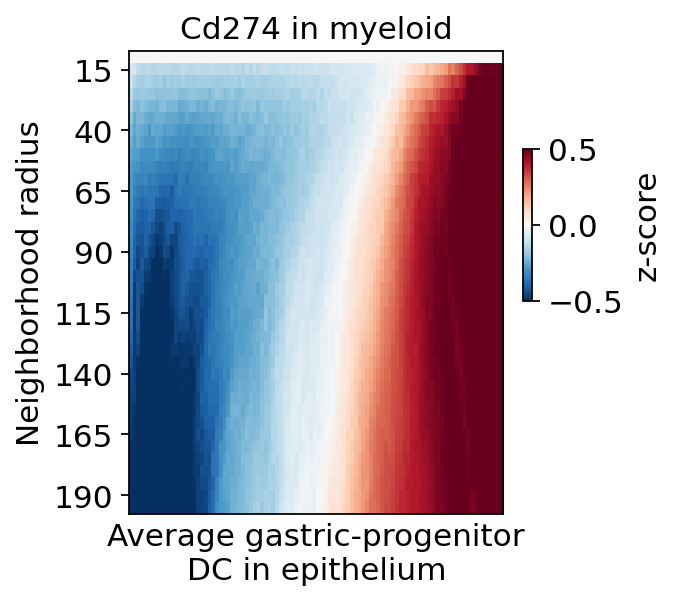

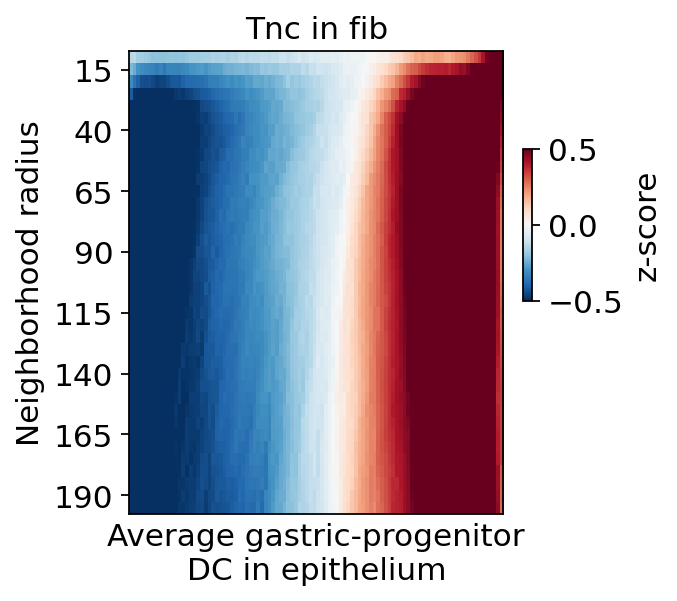

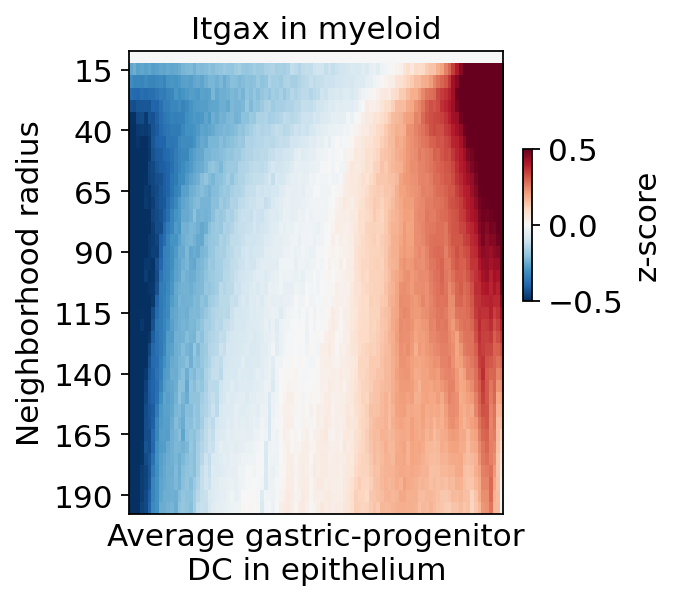

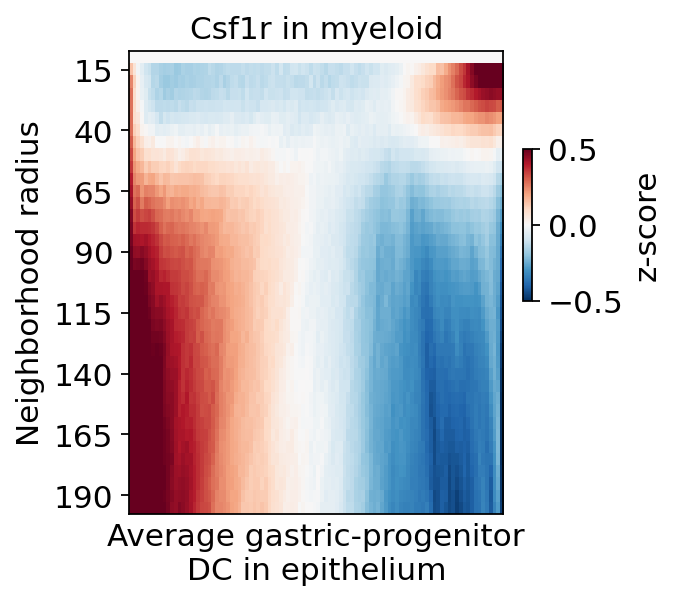

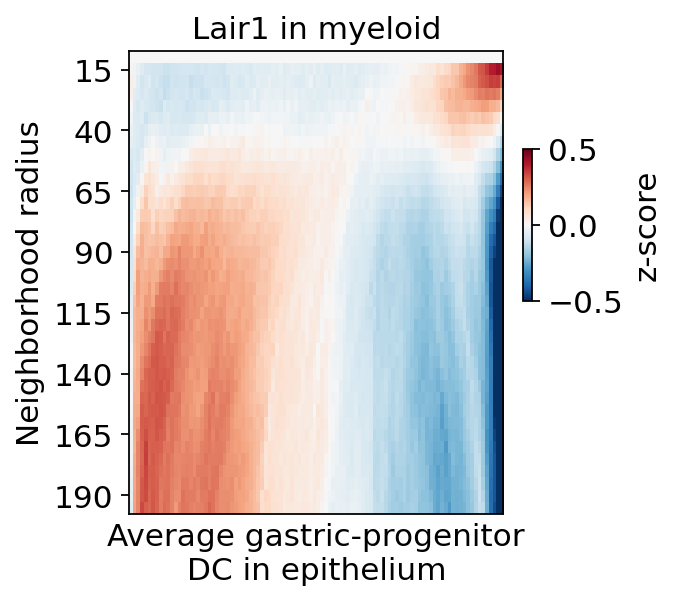

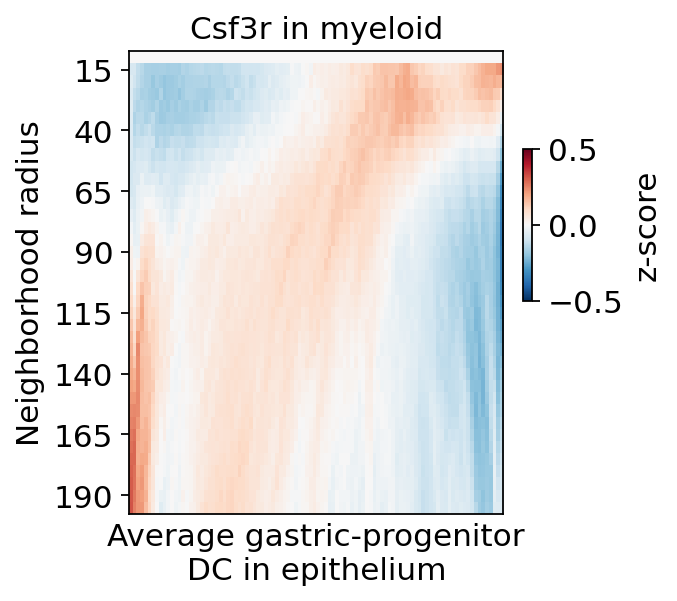

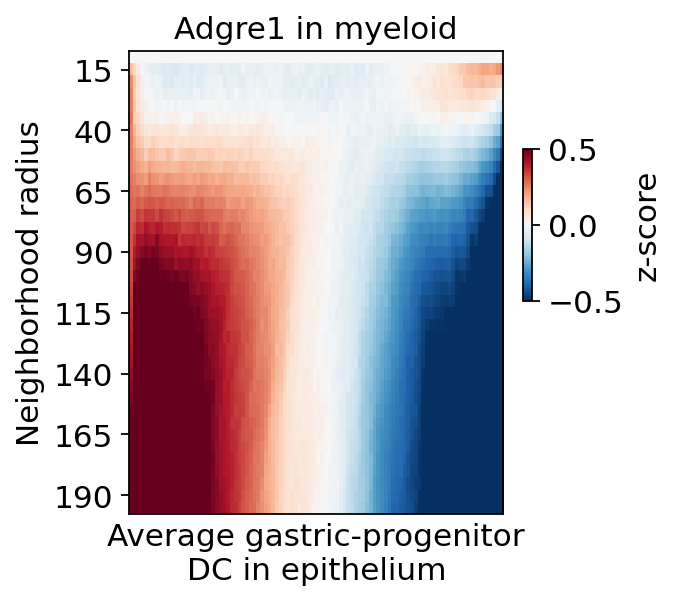

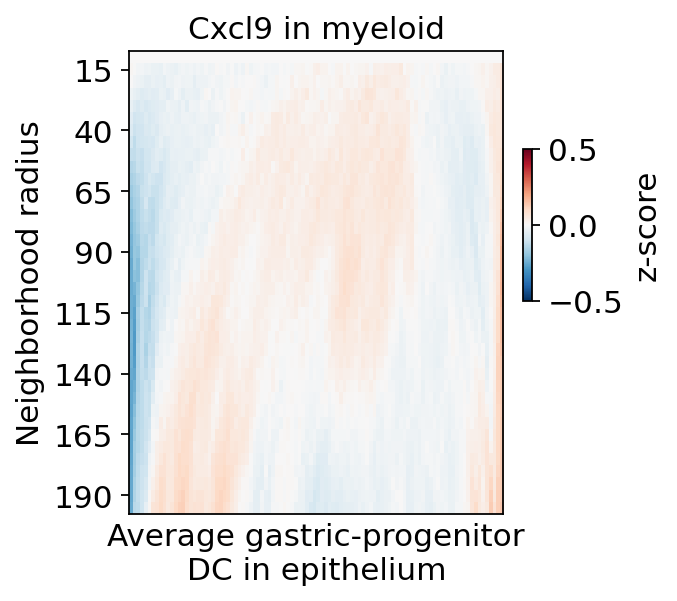

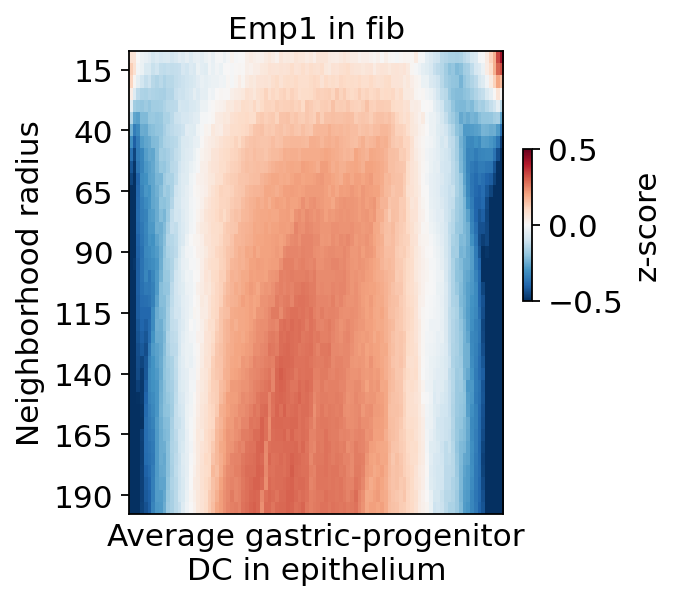

In [ ]:
plot_radius_effect("Cd274", "myeloid", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Tnc", "fib", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Itgax", "myeloid", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Csf1r", "myeloid", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Lair1", "myeloid", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Csf3r", "myeloid", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Adgre1", "myeloid", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Cxcl9", "myeloid", vmin = -0.5, vmax = 0.5, save = True)
plot_radius_effect("Emp1", "fib", vmin = -0.5, vmax = 0.5, save = True)

Plot gene trends as animation

In [ ]:
def plot_gene_trends(trends, selected_genes, vmin = -1, vmax = 1, y_lines = None, reorder_genes = True, swap_axes = False, colorbar = True, figsize_fixed = 3, figsize_scale = 0.2):
    if(reorder_genes):
        gene_ordering = order_trends(smooth_trends(trends, 3), window_length=10)
        selected_genes = gene_ordering[ismember(gene_ordering, selected_genes)[1]]
            
    trends = trends.loc[:,selected_genes].copy()
    if(not swap_axes):
        f = plt.figure(figsize=[figsize_fixed, figsize_scale*len(selected_genes)])
        trends = trends.loc[:,selected_genes].T
    else:
        f = plt.figure(figsize=[figsize_scale*len(selected_genes), figsize_fixed])
        trends.loc[:,selected_genes]
    im = plt.imshow(trends, aspect='auto', vmin=vmin, vmax=vmax, cmap='RdBu_r', interpolation = 'None')
    if not y_lines is None:
        for my_line in y_lines:
            plt.plot([my_line, my_line], f.gca().get_ylim(), 'k--')
    if(not swap_axes):
        plt.yticks(np.array(list(range(len(selected_genes)))), labels = selected_genes)
    else:
        plt.xticks(np.array(list(range(len(selected_genes)))), labels = selected_genes, rotation = 90)
    plt.xlabel("Gastric Progenitor DC")
    plt.grid(False)
    if colorbar:
        cb_ax = f.add_axes([0.5,0.5,0.02,0.25])
        f.colorbar(im,orientation='vertical',cax=cb_ax, fraction=0.01, label='z-score')
    return(trends)

100%|██████████| 38/38 [00:11<00:00,  3.45it/s]


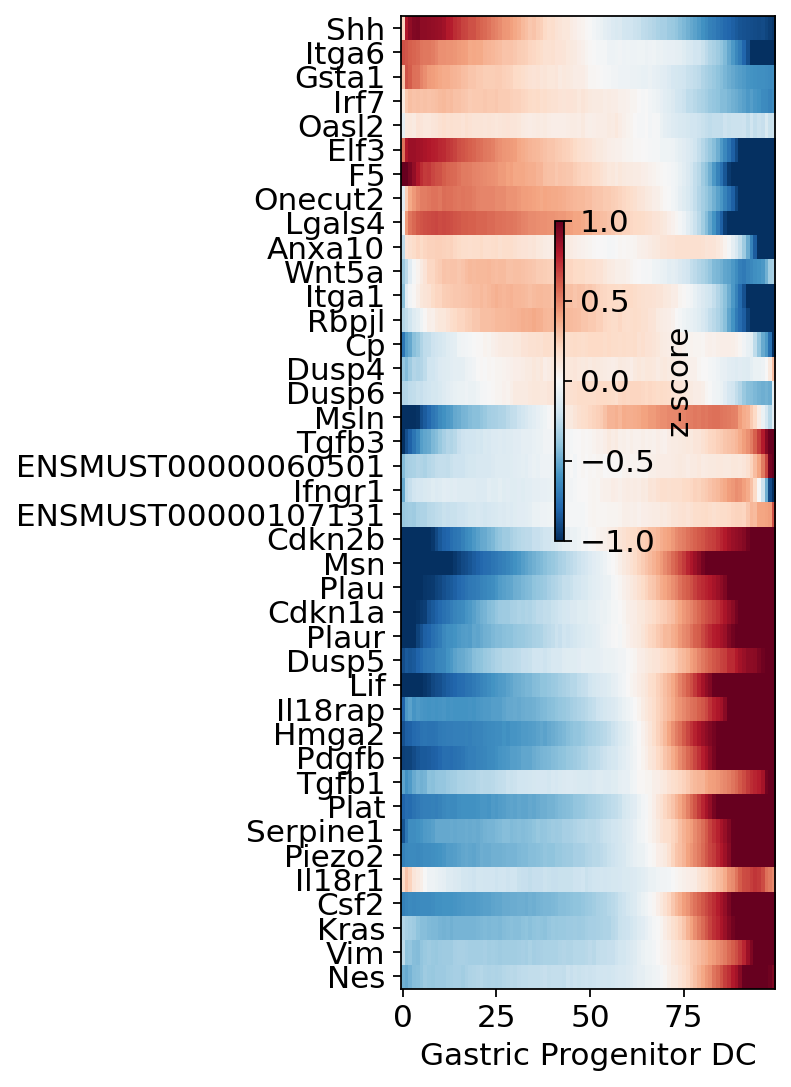

In [ ]:
gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_epi_trends_NHOODMODE_circle60.pydata")
selected_genes = plot_gene_trends(gene_trends['mean'], Xenium_epithelial_measured, vmin = -1, vmax = 1, y_lines = []).index.to_numpy()

output_path = '../animation/gene_trends_radius_preprocessing_3_epithelial'
os.makedirs(output_path, exist_ok=True)
for selected_radius in tqdm(range(10, 200, 5)):
    gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_epi_trends_NHOODMODE_circle"+str(selected_radius)+".pydata")
    _ = plot_gene_trends(gene_trends['mean'], selected_genes, vmin = -1, vmax = 1, y_lines = [], colorbar = False, reorder_genes=False)
    plt.title("radius = " + str(selected_radius))
    plt.savefig(os.path.join(output_path, "gene_trends_epi_RADIUS_" + str(selected_radius).zfill(3) + ".png"))
    plt.close()

100%|██████████| 38/38 [00:09<00:00,  3.94it/s]


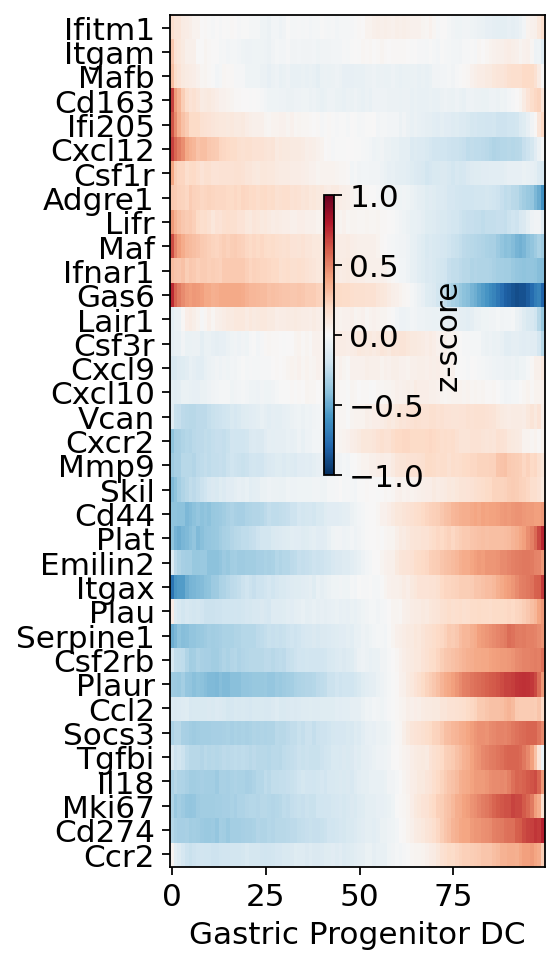

In [ ]:
gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_myeloid_trends_NHOODMODE_circle60.pydata")
selected_genes = plot_gene_trends(gene_trends['mean'], Xenium_myeloid_measured, vmin = -1, vmax = 1, y_lines = []).index.to_numpy()

output_path = '../animation/gene_trends_radius_preprocessing_3_myeloid'
os.makedirs(output_path, exist_ok=True)
for selected_radius in tqdm(range(10, 200, 5)):
    gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_myeloid_trends_NHOODMODE_circle"+str(selected_radius)+".pydata")
    _ = plot_gene_trends(gene_trends['mean'], selected_genes, vmin = -1, vmax = 1, y_lines = [], colorbar = False, reorder_genes=False)
    plt.title("radius = " + str(selected_radius))
    plt.savefig(os.path.join(output_path, "gene_trends_myeloid_RADIUS_" + str(selected_radius).zfill(3) + ".png"))
    plt.close()

100%|██████████| 38/38 [00:09<00:00,  4.12it/s]


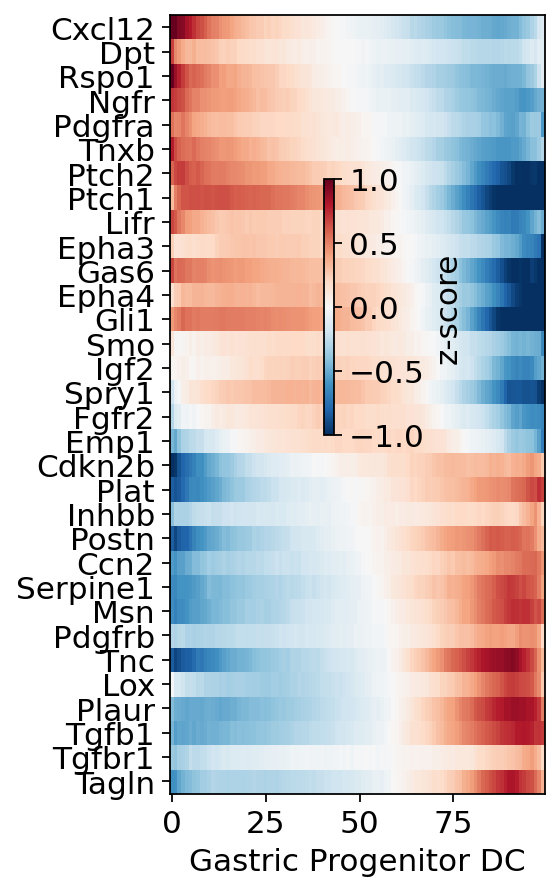

In [ ]:
gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_fib_trends_NHOODMODE_circle60.pydata")
selected_genes = plot_gene_trends(gene_trends['mean'], Xenium_fibroblast_measured, vmin = -1, vmax = 1, y_lines = []).index.to_numpy()

output_path = '../animation/gene_trends_radius_preprocessing_3_fib'
os.makedirs(output_path, exist_ok=True)
for selected_radius in tqdm(range(10, 200, 5)):
    gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_fib_trends_NHOODMODE_circle"+str(selected_radius)+".pydata")
    _ = plot_gene_trends(gene_trends['mean'], selected_genes, vmin = -1, vmax = 1, y_lines = [], colorbar = False, reorder_genes=False)
    plt.title("radius = " + str(selected_radius))
    plt.savefig(os.path.join(output_path, "gene_trends_fib_RADIUS_" + str(selected_radius).zfill(3) + ".png"))
    plt.close()

100%|██████████| 38/38 [00:00<00:00, 1428.30it/s]


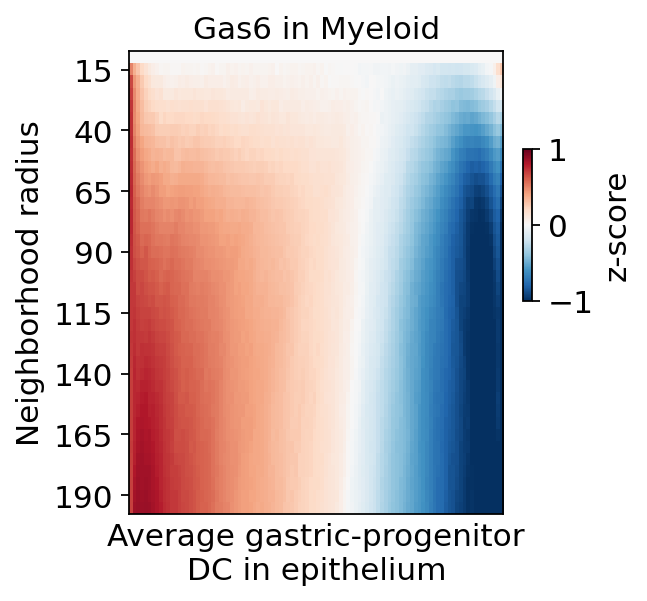

In [ ]:
selected_gene = 'Gas6'
result = []
radii = np.array(list(range(10, 200, 5)))
for selected_radius in tqdm(radii):
    gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_myeloid_trends_NHOODMODE_circle"+str(selected_radius)+".pydata")
    result.append(gene_trends['mean'][selected_gene])
result = pd.concat(result, axis = 1)
result.columns = radii

figsize_fixed = 3
figsize_scale = 0.1
f = plt.figure(figsize=[figsize_fixed, figsize_scale*result.shape[1]])
im = plt.imshow(result.T, interpolation = None, cmap = 'RdBu_r', aspect = 'auto', vmin = -1, vmax = 1)
selected_radii = np.array(list(range(1,len(radii),5)))
h = plt.gca().set_yticks(selected_radii, labels = radii[selected_radii])
plt.gca().set_xticks([])
plt.title(selected_gene + " in Myeloid")
plt.ylabel("Neighborhood radius")
plt.xlabel("Average gastric-progenitor\nDC in epithelium")

cb_ax = f.add_axes([1,0.5,0.02,0.25])
f.colorbar(im,orientation='vertical',cax=cb_ax, fraction=0.01, label='z-score')

100%|██████████| 38/38 [00:00<00:00, 1495.48it/s]


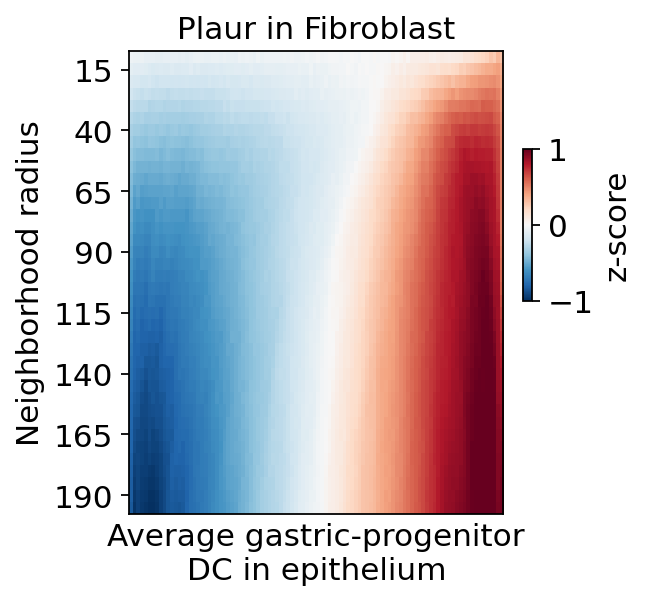

In [ ]:
selected_gene = 'Plaur'
result = []
radii = np.array(list(range(10, 200, 5)))
for selected_radius in tqdm(radii):
    gene_trends = read_object("../preprocessing_outputs_3/gene_trends/adata_tier3_fib_trends_NHOODMODE_circle"+str(selected_radius)+".pydata")
    result.append(gene_trends['mean'][selected_gene])
result = pd.concat(result, axis = 1)
result.columns = radii

figsize_fixed = 3
figsize_scale = 0.1
f = plt.figure(figsize=[figsize_fixed, figsize_scale*result.shape[1]])
im = plt.imshow(result.T, interpolation = None, cmap = 'RdBu_r', aspect = 'auto', vmin = -1, vmax = 1)
selected_radii = np.array(list(range(1,len(radii),5)))
h = plt.gca().set_yticks(selected_radii, labels = radii[selected_radii])
plt.gca().set_xticks([])
plt.title(selected_gene + " in Fibroblast")
plt.ylabel("Neighborhood radius")
plt.xlabel("Average gastric-progenitor\nDC in epithelium")

cb_ax = f.add_axes([1,0.5,0.02,0.25])
f.colorbar(im,orientation='vertical',cax=cb_ax, fraction=0.01, label='z-score')